# Iman Noor
---

# **Neural Networks Basics (Perceptron, Activation Functions)**

## 🎯 Objective
The goal is to understand the basics of neural networks, focusing on perceptrons, activation functions, and building a simple neural network from scratch for a regression task. We will use Python and NumPy for this implementation, aiming to grasp the concepts and mathematics behind neural networks without relying on high-level libraries like TensorFlow or PyTorch.

## 📚 Explanation

## **Introduction to Neural Networks**
Neural networks are computational models inspired by the human brain's structure. They consist of interconnected layers of neurons, each processing input data to extract patterns and make predictions. The basic building block of a neural network is the perceptron.

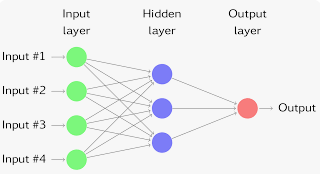

## **Perceptron**
A perceptron is the simplest form of a neural network. It consists of an input layer, weights, a bias term, and an activation function. The perceptron computes a weighted sum of the input features and passes it through an activation function to produce an output.

Mathematically, the output \( y \) of a perceptron is given by:
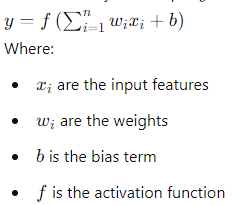

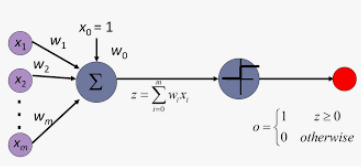

## 📌 Implementation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Generating Random Dataset for Model

In [2]:
X = np.vstack([(np.random.rand(10, 2)*5), (np.random.rand(10, 2)*10)])
Y = np.hstack([[0]*10, [1]*10])
df = pd.DataFrame(X, columns={'X1', 'X2'})
df['Y'] = Y

In [3]:
df

,X2,X1,Y
0,2.425985,0.566682,0
1,3.864432,2.981287,0
2,4.840705,4.126976,0
3,0.455089,3.043818,0
4,1.860238,2.972004,0
5,3.661248,2.978325,0
6,4.290175,1.907581,0
7,0.176258,1.890736,0
8,0.539124,3.766823,0
9,4.331654,2.004813,0


## Plotting dataset values

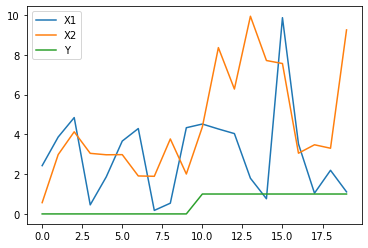

In [4]:
plt.plot(df,label='Inline label')
plt.legend(['X1', 'X2', 'Y']);

## Converting target variable to vector of number of classes

In [5]:
Z = np.zeros((20, 2))
for i in range(20):
    Z[i, Y[i]] = 1 # one hot encoding

In [6]:
X.shape

(20, 2)

## **Activation Functions**
Activation functions introduce non-linearity into the model, allowing the network to learn complex patterns. Common activation functions include:

- **Sigmoid**: 
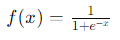

- **ReLU (Rectified Linear Unit)**: 
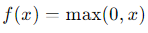


In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [8]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

## **Building a Simple Neural Network**
A basic neural network for regression consists of:
- One input layer
- One hidden layer
- One output layer

Mean Squared Error (MSE) as the loss function to measure prediction accuracy, and gradient descent to optimize the model's weights will be used.

## **Mean Squared Error (MSE)**
MSE measures the average squared difference between the actual and predicted values:
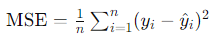

## **Gradient Descent**
Gradient descent is an optimization algorithm that iteratively updates the weights to minimize the loss function:
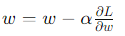
Where:
- `alpha` is the learning rate
- `L` is the loss function.


## **Initialize Random Weights and Bias**

In [9]:
Wi_1 = np.random.randn(3, 2)
Bi_1 = np.random.randn(3)
Wi_2 = np.random.randn(3, 2)
Bi_2 = np.random.randn(2)

In [10]:
Wi_1

array([[-1.0252568 , -0.22591776],
       [ 0.36618696, -0.94092902],
       [ 1.17855041, -1.07381404]])

In [11]:
Wi_2

array([[-0.61761847,  1.1477286 ],
       [ 1.05486764,  0.63709865],
       [ 0.32736165,  1.42880079]])

In [12]:
Bi_1

array([-1.0434516 ,  0.71137857, -1.38141374])

In [13]:
Bi_2

array([ 1.03475224, -0.97843173])

In [14]:
Wi_1.T

array([[-1.0252568 ,  0.36618696,  1.17855041],
       [-0.22591776, -0.94092902, -1.07381404]])

In [15]:
X.dot(Wi_1.T)

array([[ -2.61528146,   0.35515659,   2.25063481],
       [ -4.63556133,  -1.39007461,   1.3530807 ],
       [ -5.89532238,  -2.11058861,   1.2734095 ],
       [ -1.15423511,  -2.6973691 ,  -2.73214964],
       [ -2.57864987,  -2.11524952,  -0.99899504],
       [ -4.42657548,  -1.46169091,   1.11679812],
       [ -4.82948747,  -0.22389211,   3.00780029],
       [ -0.60786049,  -1.71450505,  -1.82257005],
       [ -1.40373258,  -3.34689259,  -3.40948234],
       [ -4.89398016,  -0.30019148,   2.952276  ],
       [ -5.61855147,  -2.45934771,   0.62905659],
       [ -6.26413512,  -6.29989089,  -3.9428354 ],
       [ -5.55583883,  -4.42639707,  -1.98136767],
       [ -4.08254516,  -8.69007226,  -8.5534235 ],
       [ -2.52372447,  -6.97388587,  -7.37846091],
       [-11.81738909,  -3.50048645,   3.50580494],
       [ -4.29421446,  -1.5835837 ,   0.86724874],
       [ -1.85388863,  -2.88755444,  -2.50231551],
       [ -2.99302212,  -2.30263503,  -0.96044233],
       [ -3.22522357,  -8.29456

In [16]:
# Activation function (ReLU for hidden layer)
def relu(x):
    return np.maximum(0, x)

# Derivative of ReLU
def relu_derivative(x):
    return (x > 0).astype(float)

## **Forward and Backward Passes**

In [17]:
def forward_prop(X, Wi_1, Bi_1, Wi_2, Bi_2):
    # first layer
    M = 1 / (1 + np.exp(-(X.dot(Wi_1.T)+Bi_1)))
    
    # second layer
    A = M.dot(Wi_2) + Bi_2
    expA = np.exp(A)
    Y = expA / expA.sum(axis=1, keepdims=True)
    return Y, M


In [18]:
forward_prop(X, Wi_1, Bi_1, Wi_2, Bi_2)

(array([[0.81810783, 0.18189217],
        [0.83269589, 0.16730411],
        [0.82823357, 0.17176643],
        [0.86639133, 0.13360867],
        [0.87613709, 0.12386291],
        [0.84043987, 0.15956013],
        [0.79357303, 0.20642697],
        [0.85793073, 0.14206927],
        [0.86892132, 0.13107868],
        [0.79378347, 0.20621653],
        [0.84814   , 0.15186   ],
        [0.88165721, 0.11834279],
        [0.87909009, 0.12090991],
        [0.88109588, 0.11890412],
        [0.87710857, 0.12289143],
        [0.74144887, 0.25855113],
        [0.84757633, 0.15242367],
        [0.87448977, 0.12551023],
        [0.87616735, 0.12383265],
        [0.87963439, 0.12036561]]),
 array([[2.51179671e-02, 7.43937440e-01, 7.04583592e-01],
        [3.40529388e-03, 3.36552395e-01, 4.92917212e-01],
        [9.68518505e-04, 1.97941496e-01, 4.73025155e-01],
        [9.99584157e-02, 1.20681691e-01, 1.60864081e-02],
        [2.60307431e-02, 1.97202569e-01, 8.46788759e-02],
        [4.19345899e-03, 3.2

## Backpropagation by Differentiating or Gradient Descent

In [19]:
# Gradient for weight 2
def diff_Wi_2(H, Z, Y):
    return H.T.dot(Z - Y)

In [20]:
# Gradient for weight 1
def diff_Wi_1(X, H, Z, output, Wi_2):
    dZ = (Z - output).dot(Wi_2.T) * H * (1 - H)
    return X.T.dot(dZ)

In [21]:
# Derivative for both Bias 
def diff_B2(Z, Y):
    return (Z - Y).sum(axis=0)

def diff_B1(Z, Y, Wi_2, H):
    return ((Z - Y).dot(Wi_2.T) * H * (1 - H)).sum(axis=0)

In [22]:
learning_rate = 1e-3
for epoch in range(5000):
    output, hidden = forward_prop(X, Wi_1, Bi_1, Wi_2, Bi_2)
    Wi_2 += learning_rate*diff_Wi_2(hidden, Z, output)
    Bi_2 += learning_rate*diff_B2(Z, output)
    Wi_1 += learning_rate*diff_Wi_1(X, hidden, Z, output, Wi_2).T
    Bi_1 += learning_rate*diff_B1(Z, output, Wi_2, hidden)

1. **One Input Layer**: 
   - The input layer is represented by the input data `X`, which has two features. This layer is not explicitly defined as a separate layer in the code but is represented by the input data directly.

2. **One Hidden Layer**:
   - The hidden layer is defined by the weights `Wi_1` and biases `Bi_1`.
   - The hidden layer has 3 neurons (as indicated by the shape of `Wi_1`), and it uses the ReLU activation function, which introduces non-linearity.

3. **One Output Layer**:
   - The output layer is defined by the weights `Wi_2` and biases `Bi_2`.
   - The output layer has 1 neuron (as it's a regression task predicting a single continuous value), and it uses a linear activation function, suitable for regression tasks.

### Breakdown:
- **Input Layer**: Takes in the input features (2 features per example).
- **Hidden Layer**: 
  - Applies the weights `Wi_1` and biases `Bi_1` to the input.
  - Passes the result through the ReLU activation function.
- **Output Layer**:
  - Takes the output from the hidden layer.
  - Applies the weights `Wi_2` and biases `Bi_2`.
  - Produces the final output without an additional activation function (linear output).

## Generating Prediction at New Dataset

In [23]:
X_test = np.array([9, 9])

hidden_output = 1 / (1 + np.exp(-X_test.dot(Wi_1.T) - Bi_1))
Output_layer_output = hidden_output.dot(Wi_2) + Bi_2
expA = np.exp(Output_layer_output)
Y = expA / expA.sum()
print('Probability of class 0: {} \nProbability of class 1: {}'.format(Y[0],Y[1]))

Probability of class 0: 0.017033563626437195 
Probability of class 1: 0.9829664363735627


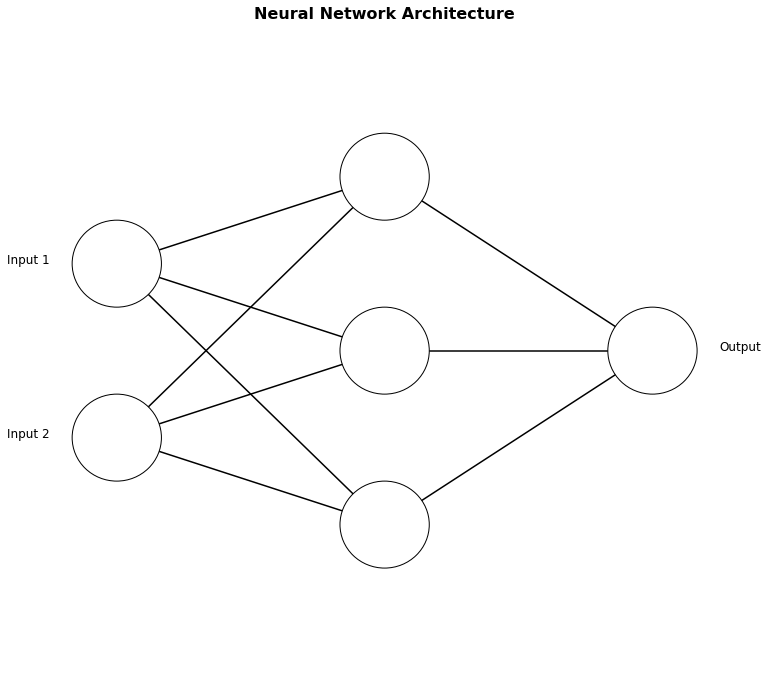

In [24]:
import networkx as nx

def draw_neural_net(ax, left, right, bottom, top, layer_sizes):
    '''
    Draw a neural network cartoon using matplotilb.
    '''
    v_spacing = (top - bottom)/float(max(layer_sizes))
    h_spacing = (right - left)/float(len(layer_sizes) - 1)

    # Nodes
    for i, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing*(layer_size - 1)/2. + (top + bottom)/2.
        for j in range(layer_size):
            circle = plt.Circle((left + i*h_spacing, layer_top - j*v_spacing), v_spacing/4.,
                                color='w', ec='k', zorder=4)
            ax.add_artist(circle)
            if i == 0:
                ax.text(left + i*h_spacing - 0.1, layer_top - j*v_spacing, f'Input {j+1}', fontsize=12, ha='right')
            elif i == len(layer_sizes) - 1:
                ax.text(left + i*h_spacing + 0.1, layer_top - j*v_spacing, 'Output', fontsize=12, ha='left')

    # Edges
    for i, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing*(layer_size_a - 1)/2. + (top + bottom)/2.
        layer_top_b = v_spacing*(layer_size_b - 1)/2. + (top + bottom)/2.
        for j in range(layer_size_a):
            for k in range(layer_size_b):
                line = plt.Line2D([left + i*h_spacing, left + (i + 1)*h_spacing],
                                  [layer_top_a - j*v_spacing, layer_top_b - k*v_spacing], c='k')
                ax.add_artist(line)

fig = plt.figure(figsize=(12, 12))
ax = fig.gca()
ax.axis('off')
draw_neural_net(ax, .1, .9, .1, .9, [2, 3, 1])  # 2 input nodes, 3 hidden nodes, 1 output node
plt.title("Neural Network Architecture",weight='bold',fontsize=16)
plt.show()

# **The End :)**